### **Training Linear and Non Linear models**

We implemented four models: a logistic regression (linear), a K-nearest neighbors algorithm (non-linear), a random forest (non-linear), and a neural network (non-linear). All four specifications are built on the same dataset and have been tuned to identify the corresponding optimal hyperparameters via cross-validation and make comparisons as reliable as possible. We focus our analysis of model performance on prediction accuracy and recall. Let's dive deeper into them.

**1. Linear Model: Logistic Regression with Elasticnet Regularization**

Our baseline model specification is defined by the following logistic regression:

$$
P(y_i = +1 | x_i)  = \sigma (w^Tx_i + b) = \frac{1}{1+e^{-(w^Tx_i + b)}}
$$

where $i$ is one of 50km x 50km grids in Africa ~ _our samples_, 

We fit this model by minimizing the conditional log-likelihood of $y_i$ given $x_i$ using the following negative log-loss function, which includes an _elastic net_ regularizer:

$$
\ell(w,b) = - \sum_{i=1}^n \left[ \log \sigma(y_i(w^T x_i + b)) \right] + \lambda \left[ \alpha \sum_{j = 1}^p |w_j| + (1 - \alpha) \sum_{j = 1}^p w_j^2 \right]
$$

We have opted for a logistic regression specification due to its ability to predict the likelihood of an event happening, in this case the occurence and/or how violent the encounter, based on contextual attributes assigned to a specific geography. Also, we chose because of it's ease of adapting to our expectations of training a multinomial logistic specification to classify grids into no conflict, low conflict and high conflict classes. 

Besides computing the dot product of the features and their weights, alongside the model bias, we added a regularization term to control overfitting that may arise due to the correlations between some of our features (`light_sum` and `light_mean`) as well as the concentration of our label variable around the zero class (no conflict). We define this term as an elastic net to parametrize the model in terms of a mix between L1 and L2.

To interpret the weights in our logistic regression model, we first standardized all features using StandardScaler. This transformation ensures all variables have mean=0 and standard deviation=1, making weight magnitudes directly comparable. After standardization, larger positive weights indicate features that strongly increase conflict **probability**, while large negative weights represent factors that decrease conflict likelihood. For example, a large positive weight for "accumulated_conflicts" would suggest past conflict history strongly predicts future conflicts, while a negative weight for "rwi_2021" might indicate wealthier areas experience fewer conflicts.

Also, due to the imbalance of our dataset (~92% of data is labeled with no conflict at all) we had to apply a Synthetic Minority Over-sampling Technique (SMOTE) to create artificial (not duplicates) values of the conflict class (label = 1). Without doing this, the model would be heavily biased toward the majority class (no conflict at all) and would have a high accuracy by ignoring the minority classes.

For this model, we tuned two main hyperparameters: 

- $\alpha$: Which is the proportion of L1 regularizator and $(1- \alpha)$ being the proportion of L2 regularizator. This is the Elasticnet we talked before.$

    We tuned the parameter using five different options of $\alpha$. They were $[0, 0.25, 0.5, 0.75, 1.0]$.

- $\lambda$: Is the value on how hard is the penalty applied. A low $\lambda$ means a weak penalization, while a higher $\lambda$ means a strong penalization. (In the code you will not see $\lambda$ but the $C$ parameter, where $\lambda = 1/C$)

    We tuned the parameter using five different options of $C$. They were $C = [0.001, 0.01, 0.1, 1, 10]$, meaning in practical terms the following $\lambda$ = $[1000, 100, 10, 1, 0.1]$

- Finally, we set 1.000 iterations as the maximum number of iterations for the model before it's convergence. 

**Cross-validation:**

- $\alpha$: From all possibilities mentioned before we got that our best $\alpha$ is $0$, meaning meaning that our linear regression will have only a L2 regularizator.

- $\lambda$: According to our model, the value that maximizes our recall is a $C=10$ implying a $\lambda = 0.1$. With it we can say that we will use a weak penalty regardless on how the penalty is composed.


**Performance:**

- As we commented before we are focusing on the maximization of the recall measure. Then we are reporting two recalls:

    - On the SMOTE training data (the one with the balanced data) our model got a 0.8176 weighted recall. Remember that this is based on synthetic data and not in the real testing data.

    - On the testing data our model got a 0.85 weighted recall, having and better performance with the dominant class (no conflict) than with the minority class (0.86 vs 0.75). The main results for them are as follow: 


$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.98 & 0.86 & 0.91 & 6251 \\
1 & 0.32 & 0.75 & 0.45 & 552 \\
\hline
\text{Accuracy} & 0.85 &  &  & 6803 \\
\text{Macro avg} & 0.65 & 0.81 & 0.68 & 6803 \\
\text{Weighted avg} & 0.92 & 0.85 & 0.88 & 6803 \\
\end{array}
$$

Confusion Matrix:

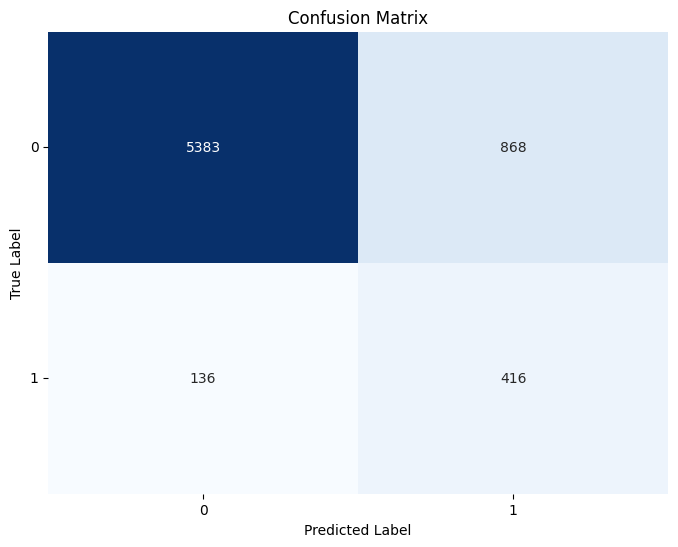



**2. Non-Linear Model: K-Nearest Neighbors**

Based on the assumption that conflict is likely to spread across geographies, and that similar geographies are likely to experience comparable levels of conflict, we implement a K-Nearest Neighbors (K-NN) algorithm. We classify each 50km x 50km grid sample $i$ by calculating the distance between its feature vector $x_i$ and the feature vectors of all other data points $x_j$ (where $j = n - i$), and sort the data ascendingly on this metric. We then define a set of $k$ nearest neighbors $S_k$ as the $k$ samples for which the distance metrics from $i$ are the smallest:  

$$\text{dist}(x_i, x_{j\notin S_k}) \geq \max_{j \in S_k} \text{ dist}(x_i, x_j)$$

In other words, we select $S_k$ so that all data points $x_j$ not in $S_k$ are at least as far away from $x_i$ as the the point in $S_k$ that is farthest from $x_i$[^1]. 


We assign label $\hat{y_i}$ as the majority class observed among labels in $S_k$:

$$\hat{y_i} = \text{mode}({y_{j \in S_k}})$$

Our K-NN model is optimized on the following parameters: 

- $K$: The nearest neighbors from which to assign a label to $i$, where $K$ is one of $[3,5,7,9,11]$. Possible values of $K$ are all odd to prevent ties when predicting binary label based on majority. 
- $\text{dist}$: the distance metric to use when comparing samples:
    - Euclidean: $$D_{\text{euc}}(x_i, x_j) = \sqrt{\sum_{m=1}^p{(x_{im} - x_{jm})^2}}; \text{p = no. of features}$$

    - Cosine similarity: $$D_{\cos}(x_i, x_j) = \frac{x_i * x_j}{\|x_i\| \|x_j\|}$$

Additionally, we include uniform- and distance-weighted K-NN specifications when using the euclidean metric to account for the potential shortcomings of this distance-based learning in higher dimensions. The latter grants stronger predictive influence to samples that are closer in distance to sample $i$. 

**Cross-validation**

We find that the K-NN model that performs the best on the data is the one that uses **cosine similarity** as distance metric with $K = 3$. 

**Performance** 

$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.97 & 0.90 & 0.93 & 6236 \\
1 & 0.38 & 0.68 & 0.49 & 567 \\
\hline
\text{Accuracy} & 0.88 &  &  & 6803 \\
\text{Macro avg} & 0.68 & 0.79 & 0.71 & 6803 \\
\text{Weighted avg} & 0.92 & 0.88 & 0.9 & 6803 \\
\end{array}
$$

[^1]: https://www.cs.cornell.edu/courses/cs4780/2017sp/lectures/lecturenote02_kNN.html

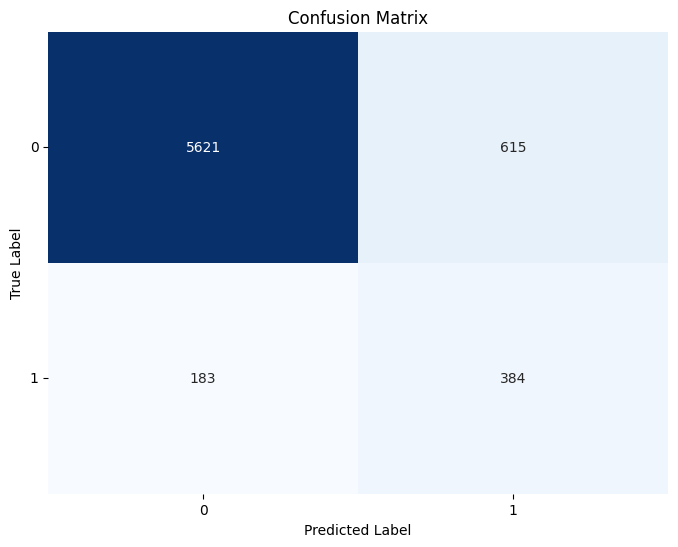